# PalmSens `.pssession` Folder Workflow

This notebook shows the direct PalmSens route. If your raw data are PalmSens `.pssession` files, you do not need to manually build a structured CSV first. Point ASWIFT at a folder of `.pssession` files and the batch helpers will:

1. read the PalmSens files,
2. extract each SWV trace as a full `voltage` array and full `current` array,
3. preserve metadata such as file, timestamp, frequency, channel, and trace label,
4. preserve relative time so the earliest measurement is `0.0`,
5. fit the traces, and
6. return the same structured raw `results` dataframe that can be saved as JSON and opened in the Streamlit viewer.

The `.pssession` reader requires the optional `pypalmsens` package. Set `PSSESSION_ZIP_URL` or `PSSESSION_FOLDER` once public example data is available.


In [1]:
from pathlib import Path
import sys
import urllib.request
import zipfile

import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "src" / "aswift").exists():
        repo_root = candidate
        break
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from aswift import (
    fit_pssession_folder,
    plot_signal_over_time,
    pssession_folder_to_dataframe,
    strip_mp3_suffix_from_pssession_files,
)


## Download Or Point To Example Data

Good public options later:

- GitHub Releases for a small zip file attached to a release.
- Zenodo for a citable DOI and larger files.
- OSF or Figshare for public research datasets.

The downloaded zip should contain `.pssession` files directly or in a single extracted folder.

If files arrive as `.pssession.mp3`, the next cell strips only the final `.mp3` suffix before checking for `.pssession` files.

In [2]:
PSSESSION_ZIP_URL = None  # e.g. "https://github.com/<org>/<repo>/releases/download/v0.1/pssession_demo.zip"
PSSESSION_ZIP_PATH = Path("data/pssession_demo.zip")
PSSESSION_FOLDER = Path("data/pssession_demo")
PSSESSION_FOLDER = Path('/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_SELEX/01_Binding Curve')

if PSSESSION_ZIP_URL and not PSSESSION_FOLDER.exists():
    PSSESSION_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(PSSESSION_ZIP_URL, PSSESSION_ZIP_PATH)
    PSSESSION_FOLDER.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(PSSESSION_ZIP_PATH) as zf:
        zf.extractall(PSSESSION_FOLDER)

renamed_files = []
if PSSESSION_FOLDER.exists():
    renamed_files = strip_mp3_suffix_from_pssession_files(PSSESSION_FOLDER)

pssession_files = sorted(PSSESSION_FOLDER.glob("*.pssession")) if PSSESSION_FOLDER.exists() else []
len(renamed_files), renamed_files[:3], len(pssession_files), pssession_files[:3]

(0,
 [],
 135,
 [PosixPath('/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_SELEX/01_Binding Curve/100hz-1.pssession'),
  PosixPath('/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_SELEX/01_Binding Curve/100hz-10.pssession'),
  PosixPath('/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_SELEX/01_Binding Curve/100hz-11.pssession')])

## Convert PalmSens Files To The Structured SWV DataFrame

`pssession_folder_to_dataframe` converts a folder of `.pssession` files into the same array-per-trace shape used by notebook 02: one row per voltammogram, with `voltage` and `current` containing full arrays plus metadata columns.

The output includes metadata such as `file`, `timestamp`, `hz`, `channel`, `label`, `voltage`, and `current`. Timestamps are read from PalmSens UTC metadata when available, and `time` is stored in hours relative to the earliest measurement.


In [3]:
if pssession_files:
    swv_df = pssession_folder_to_dataframe(PSSESSION_FOLDER)
    display(swv_df.head())
else:
    swv_df = None
    print("Set PSSESSION_ZIP_URL or PSSESSION_FOLDER to run this section with real .pssession files.")

,folder,file,hz,num,channel,label,timestamp,device,voltage,current,time
0,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz.pssession,100.0,0,0,channel5,2025-05-06 23:43:46.836779+00:00,"DeviceInfo(type='PalmSens4', firmware='1.6 Oct...","[-0.449025, -0.448009, -0.447072, -0.446056, -...","[0.225378, 0.2383, 0.215126, 0.21813, 0.237299...",0.000000
1,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,200hz.pssession,200.0,1,0,channel5,2025-05-06 23:43:54.305913+00:00,"DeviceInfo(type='PalmSens4', firmware='1.6 Oct...","[-0.449025, -0.448009, -0.447072, -0.446056, -...","[0.322606, 0.302006, 0.292707, 0.320174, 0.318...",0.002075
2,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,250hz.pssession,250.0,2,0,channel5,2025-05-06 23:43:59.247132+00:00,"DeviceInfo(type='PalmSens4', firmware='1.6 Oct...","[-0.449025, -0.448009, -0.447072, -0.446056, -...","[0.292326, 0.37315, 0.312067, 0.292374, 0.3362...",0.003447
3,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.pssession,100.0,3,0,channel5,2025-05-06 23:44:03.683141+00:00,"DeviceInfo(type='PalmSens4', firmware='1.6 Oct...","[-0.449025, -0.448009, -0.447072, -0.446056, -...","[0.201345, 0.223948, 0.223852, 0.196815, 0.194...",0.004680
4,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,200hz-1.pssession,200.0,4,0,channel5,2025-05-06 23:44:11.152738+00:00,"DeviceInfo(type='PalmSens4', firmware='1.6 Oct...","[-0.449025, -0.448009, -0.447072, -0.446056, -...","[0.290752, 0.308586, 0.290419, 0.256849, 0.327...",0.006754


## Fit All Traces With Threads

`fit_pssession_folder` combines the conversion and fitting steps. It returns both the structured SWV dataframe and the structured results dataframe. The results are ordered by timestamp, frequency, file/sample number, and channel when those columns are available.


In [4]:
if pssession_files:
    swv_df, results = fit_pssession_folder(
        PSSESSION_FOLDER,
        method="aswift",  # or "poly_linear"
        n_workers=1,
    )
    display(results[["file", "hz", "channel", "peak", "peak_voltage", "success"]].head())
else:
    results = None
    print("No .pssession files found yet.")

,file,hz,channel,peak,peak_voltage,success
0,100hz.pssession,100.0,0,0.783135,-0.233789,True
1,200hz.pssession,200.0,0,1.098664,-0.232775,True
2,250hz.pssession,250.0,0,1.219707,-0.231836,True
3,100hz-1.pssession,100.0,0,0.768797,-0.233789,True
4,200hz-1.pssession,200.0,0,1.094806,-0.232775,True


## Save Outputs

In [5]:
OUTPUT_DIR = Path("outputs/pssession_demo")

if results is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    swv_df.to_csv(OUTPUT_DIR / "pssession_long_form.csv", index=False)
    results.to_json(OUTPUT_DIR / "pssession_fit_results.json", orient="records", indent=2)

    import socket
    import subprocess
    import time


    def available_port(preferred=8501):
        for port in (preferred, 0):
            with socket.socket() as sock:
                try:
                    sock.bind(("localhost", port))
                except OSError:
                    continue
                return sock.getsockname()[1]
        raise RuntimeError("Could not find an available Streamlit port.")


    import aswift.analysis.structured_results_viewer as aswift_viewer

    viewer_script = Path(aswift_viewer.__file__).resolve()
    results_json = (OUTPUT_DIR / "pssession_fit_results.json").resolve()
    port = available_port()
    viewer_process = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "streamlit",
            "run",
            "--server.headless=true",
            f"--server.port={port}",
            str(viewer_script),
            "--",
            str(results_json),
        ],
        cwd=repo_root,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )
    time.sleep(1)
    if viewer_process.poll() is not None:
        raise RuntimeError("Streamlit failed to start. Confirm streamlit is installed in this notebook kernel.")
    print(f"Saved results to {results_json}")
    print(f"Streamlit viewer running at http://localhost:{port} with results loaded")
    print(f"Streamlit process id: {viewer_process.pid}")
else:
    print("Fit results are not available yet.")


Saved results to /Users/Max_1/PycharmProjects/aswift/examples/outputs/pssession_demo/pssession_fit_results.json
Streamlit viewer running at http://localhost:8501 with results loaded
Streamlit process id: 10481


## Stop The Streamlit Viewer

Run this cell when you are done with the browser tab to stop the background Streamlit process started above.


In [6]:
if "viewer_process" in globals() and viewer_process.poll() is None:
    viewer_process.terminate()
    try:
        viewer_process.wait(timeout=5)
    except subprocess.TimeoutExpired:
        viewer_process.kill()
        viewer_process.wait(timeout=5)
    print("Streamlit viewer stopped.")
elif "viewer_process" in globals():
    print("Streamlit viewer is already stopped.")
else:
    print("No Streamlit viewer process was started in this notebook session.")


Streamlit viewer stopped.


## Plot Signal Over Time

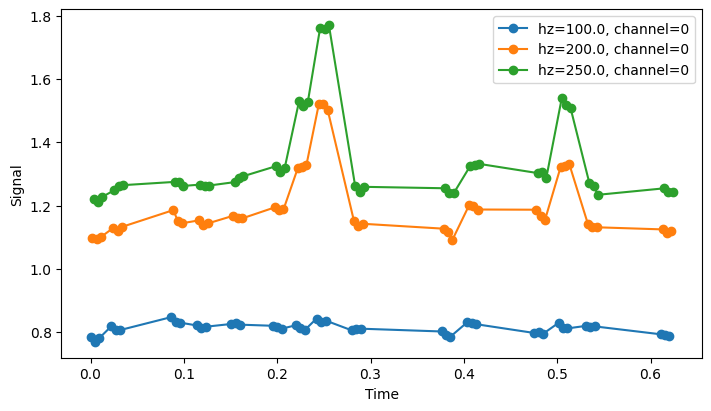

In [7]:
if results is not None:
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    plot_signal_over_time(results, ax=ax)
    plt.show()
else:
    print("Fit results are not available yet.")